# Plotting covariance matrices

This is a notebook in which we can plot the results of our covariance matrix generation

### 1 Packages <a id='packages'></a>
[Back to content](#content)

In [18]:
# Load packages, including CAMB
%matplotlib inline
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
# Use TeX
from matplotlib import rc
rc('text', usetex=False)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

from scipy import constants, special, integrate, stats
import numpy as np
from scipy.interpolate import CubicSpline, RegularGridInterpolator
from hankel import HankelTransform
import pickle
import itertools
from typing import Dict, Tuple, Any

camb_path = os.path.realpath(os.path.join(os.getcwd(),'..'))
sys.path.insert(0,camb_path)
import camb
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

from config import *
from functions.useful_functions import *

Using CAMB 1.5.9 installed at /home/masse/johnson/lenstronomyenv/lib64/python3.9/site-packages/camb


### 2 Reading in matrix data <a id='usefulfunctions'></a>

In [36]:
correlations_list = []

# Define structure for each folder: (index count, correlation file pattern)
# The correlation pattern is a format string that can include `{b1}` for indexing, or be plain text if no index is used.
folder_structure = {
    "LLLL": (0, ["plus_correlation", "minus_correlation"]),  # No redshift binning, plus and minus correlations
    "LLLp": (1, None),  # 1 redshift bin index, no correlations
    "LpLp": (2, ["correlation{b1}"]),  # 2 redshift bin indices, correlations indexed by `b1`
    "LLLe": (1, None),  # 1 redshift bin index, no correlations
    "LeLe": (2, ["plus_correlation{b1}", "minus_correlation{b1}"]),  # 2 redshift bin indices, correlations indexed by `b1`
    "LpLe": (2, None),  # 2 redshift bin indices, no correlations
}

# folder_name = matrices_folder
folder_name = 'matrices_1e9_v1'

def read_all_matrices(base_folder=matrices_folder):
    """
    Reads covariance and correlation matrices from subdirectories.
    The indexing structure is determined dynamically for each folder.
    
    Returns a nested dictionary where:
      - Covariance matrices are stored as {folder: {indices: matrix}}
      - Correlation functions are stored separately if specified.
    """

    data = {}  # Master dictionary for all data

    for folder, (index_count, correlation_patterns) in folder_structure.items():   #loop through the folders ("LLLL", "LLLp" etc), the index counts (0, 1 or 2 for the redshift binning) and the correlation function patterns from the above pattern we defined
        folder_path = os.path.join(base_folder, folder)  #define the path to the folder by joining the base path and the name of the specific folder we're interested in
        if not os.path.exists(folder_path):  #print a warning if this folder doesn't exist
            print(f"Warning: Folder {folder_path} does not exist. Skipping...")
            continue

        data[folder] = {}  # Create a sub-dictionary for the folder

        # Read correlation functions if applicable
        if correlation_patterns:    #ie we just skip the cases where there are no correlation functions, like LLLe
            for pattern in correlation_patterns: #either just correlation{b1}, or looping through the plus and minus
                if "{b1}" in pattern: #if there is redshift binnings
                    for b1 in range(5):              #loop through the redshift bins
                        correlation_file = pattern.format(b1=b1) # Format the pattern (e.g., "plus_correlation{b1}" → "plus_correlation0")
                        file_path = os.path.join(folder_path, correlation_file) #define the path to the file

                        try:
                            with open(file_path, "rb") as f:
                                if pattern not in data[folder]:  #assuming we haven't already added this correlation function
                                    data[folder][pattern] = {}   #define a dictionary within the dictionary of interest to hold the correlation function/s. This dictionary will be called "correlation" or "plus_correlation" or "minus_correlation"
                                data[folder][pattern][b1] = pickle.load(f) #store the correlation function data
                                for i in range(len(data[folder][pattern][b1])):
                                    correlations_list.append(data[folder][pattern][b1][i])
                        except Exception as ex:
                            print(f"Error reading {correlation_file} in {folder}: {ex}")
                else: #if there is no redshift binning
                    file_path = os.path.join(folder_path, pattern) #define the path to the file

                    try:
                        with open(file_path, "rb") as f:
                            if pattern not in data[folder]:  #assuming we haven't already added this correlation function
                                data[folder][pattern] = {}   #define a dictionary within the dictionary of interest to hold the correlation function/s. This dictionary will be called "correlation" or "plus_correlation" or "minus_correlation"
                            data[folder][pattern] = pickle.load(f) #store the correlation function data
                            for i in range(len(data[folder][pattern])):
                                correlations_list.append(data[folder][pattern][i])
                    except Exception as ex:
                        print(f"Error reading {correlation_file} in {folder}: {ex}")

        # Generate index combinations dynamically
        index_ranges = [range(5)] * index_count  # e.g., for (b1, b2) → [range(5), range(5)]
        for indices in itertools.product(*index_ranges):  #loops through all possible combinations
            indices_str = "".join(map(str, indices))  # Convert tuple to string for file naming (e.g. 00 or 13 etc)
        
            for name in ["ccov", "ncov", "scov"]:  #for each of the sources of covariance 
                file_path = os.path.join(folder_path, f"{name}{indices_str}")   #identify the file path of the corresponding matrix, e.g. ccov04
                try:
                    with open(file_path, "rb") as f:  #open the file
                        loaded_data = pickle.load(f)  # Load the full dictionary
                        full_matrix = loaded_data.get("full", None)  #access specifically the combined matrix, or return None if that doesn't exist
                        if full_matrix is not None: #assuming the matrix does exist
                            if name not in data[folder]:    #if the specific type of covariance (cosmic, sparsity or noise) hasn't yet been defined
                                data[folder][name] = {}     #initialise the dictionary
                            data[folder][name][indices] = full_matrix  # Store only 'full' part of the dictionary (ie the combined matrix)
                        else:
                            print(f"Warning: 'full' key missing in {file_path}")
                except Exception as ex:
                    print(f"Error reading {name}{indices_str} in {folder}: {ex}")

    return data

# Run function
matrices_data = read_all_matrices(base_folder=folder_name)

Error reading ccov in LLLL: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLL/ccov'
Error reading ncov in LLLL: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLL/ncov'
Error reading ccov0 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/ccov0'
Error reading scov0 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/scov0'
Error reading ccov1 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/ccov1'
Error reading ncov1 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/ncov1'
Error reading scov1 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/scov1'
Error reading ccov2 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/ccov2'
Error reading ncov2 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/ncov2'
Error reading ccov3 in LLLp: [Errno 2] No such file or directory: 'matrices_1e9_v1/LLLp/ccov3'
Error reading ncov3 in LLLp: [Errno 2] No such file or

### 2 Constructing large matrices <a id='usefulfunctions'></a>

In [21]:
def construct_large_matrices(matrices_data: Dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]: 
    """
    Constructs three large matrices for noise, cosmic, and sparsity covariances.
    
    Args:
        matrices_data: Dictionary containing ncov, ccov, and scov matrices
    
    Returns:
        Tuple of three matrices (noise, cosmic, sparsity)
    """
    def get_block_dimensions(matrix_dict: Dict[str, Dict[Tuple, np.ndarray]]) -> Dict[str, Tuple[int, int]]:
        """
        Constructs a dictionary of block sizes
        
        Args:
            matrices_data: Dictionary where
                            > the keys are strings (eg 'LLLL')
                            > the values are dictionaries, where 
                                - the keys are tuples representing index combinations, eg (), (b1,) or (b1,b2)
                                - the values are matrices
        
        Returns:
            Tuple of three matrices (noise, cosmic, sparsity)
        """
            
        block_sizes = {} #initialise an empty dictionary to store the block sizes   
        for matrix_type, matrices in matrix_dict.items():   #loop through the matrix types (LLLL, LLLe etc) and the corresponding matrix dictionaries (possibly indexed by redshift)
            if not matrices: #skip if the matrix is empty
                continue
            first_matrix = next(iter(matrices.values()))  #extracts the first matrix from the dictionary
            if isinstance(first_matrix, np.ndarray):      #if indeed the first matrix is a numpy ndarray
                rows, cols = first_matrix.shape           #extract the number of rows and columns of the first matrix (we only need to check the first because they should all be the same within a given matrix_type)
                block_sizes[matrix_type] = (rows, cols)   #the value within the block sizes dictionary (indexed by the matrix name) is defined by the number of rows and columns
        return block_sizes
    
    def create_single_matrix(cov_type: str) -> np.ndarray: 
        """
        Constructs a single large covariance matrix of a given type (eg sparsity or noise)
        
        Args:
            a string representing the matrix type (ccov, ncov or scov)
        
        Returns:
            np.ndarray (matrix)
        """
        matrices = {folder: matrices.get(cov_type, {}) 
                   for folder, matrices in matrices_data.items()}   #extracts all of the matrices which are the correct type (sparsity, noise or cosmic)
        
        # Get block sizes. Each block represents an individual combination of correlation functions and redshift bins (eg there is a single block corresponding to LeLe (2,3)
        block_sizes = get_block_dimensions(matrices) #extract the sizes of each matrix
        if not block_sizes:
            return None
        
        # Determine number of bins
        bins_dict = {}
        for matrix_type, matrix_dict in matrices.items():
            if matrix_type == 'LLLL':
                bins_dict[matrix_type] = (1, 1)
                continue
            if matrix_dict:
                index_lengths = {len(idx) for idx in matrix_dict.keys()}
                
                if index_lengths == {1}:  # Indexed by a single bin (e.g., LLLe)
                    max_index = max(idx[0] for idx in matrix_dict.keys())
                    bins_dict[matrix_type] = (1, max_index + 1)
                elif index_lengths == {2}:  # Indexed by two bins (e.g., LeLe)
                    max_b1 = max(idx[0] for idx in matrix_dict.keys())
                    max_b2 = max(idx[1] for idx in matrix_dict.keys())
                    bins_dict[matrix_type] = (max_b1 + 1, max_b2 + 1)
                else:
                    raise ValueError(f"Unexpected index structure for {matrix_type}: {index_lengths}")

        nrows = 0
        ncolumns = 0
        
        for matrix_type in folder_structure.keys():   #loop through the matrix types (LLLL, LLLe etc) 

            if folder_structure[matrix_type][1] is not None: #basically, we only consider the diagonal blocks - LLLL, LeLe and LpLp
                nrows += block_sizes[matrix_type][0]*bins_dict[matrix_type][0]        #the number of rows is given by the sum of all the rows in each of these blocks
                ncolumns += block_sizes[matrix_type][1]*bins_dict[matrix_type][1]     #ditto for columns
        
        large_size = (nrows, ncolumns)
        
        # Initialize matrix
        large_matrix = np.zeros(large_size)           #we initialise the matrix with the required dimensionality

        def ngen(folder, idx):
            return bins_dict[folder][idx] * block_sizes[folder][idx]
        
        matrix_structure = {'LLLL' : (0,0),
                            'LLLp' : (0, ngen('LLLL', 1)),
                            'LLLe' : (0, ngen('LLLL', 1) + ngen('LLLp', 1)),
                            'LpLp' : (ngen('LLLL', 0), ngen('LLLL', 1)),
                            'LpLe' : (ngen('LLLL', 1) + ngen('LLLp', 1), ngen('LLLL', 0)),
                            'LeLe' : (ngen('LLLL', 0) + ngen('LpLp', 0), ngen('LLLL', 1) + ngen('LpLp', 1))                        
                            }

        def start_pos(folder, b, idx):
            """
            folder - eg LLLL
            b - redshift binning
            idx - row (0) or column (1)
            """
            
            return matrix_structure[folder][idx] + b*block_sizes[folder][idx]

        def insert_block(matrix: np.ndarray, brow, bcol, matrix_type, transpose: bool = False):
            """
            Adds a block to the large matrix
            
            Args:
                matrix - the matrix to which the block is being added
                row_idx - an index of the row we are interested in
                column_idx - an index of the column we are interested in
                blocksize - the dimensions of a subblock of the block we are adding (eg (10,10) for LLLL)
                transpose - whether or not to transpose the matrix
            
            Returns:
                np.ndarray (the same matrix we began with, but now with our block added)
            """
            if matrix is None:
                return

            matrix_to_insert = matrix.T if transpose else matrix    #if transpose is true, then insert the transpose of the matrix
            current_shape = matrix_to_insert.shape                  #gives the shape of the matrix we want to insert

            if transpose:
                col_start = start_pos(matrix_type, brow, 0)
                row_start = start_pos(matrix_type, bcol, 1)

            else:
                row_start = start_pos(matrix_type, brow, 0)
                col_start = start_pos(matrix_type, bcol, 1)
            
            row_end = row_start + current_shape[0]
            col_end = col_start + current_shape[1]
            
            large_matrix[row_start:row_end, col_start:col_end] = matrix_to_insert

        
        # Insert blocks for each matrix type
        if 'LLLL' in matrices and () in matrices['LLLL']:
            insert_block(matrices['LLLL'][()], 0, 0, 'LLLL')
        
        if 'LLLp' in matrices:
            for b in range(bins_dict.get('LLLp', 0)[1]):
            # for b in range(1):
                if (b,) in matrices['LLLp']:
                    insert_block(matrices['LLLp'][(b,)], 0, b, 'LLLp')
                    insert_block(matrices['LLLp'][(b,)], 0, b, 'LLLp', transpose=True)
        
        if 'LpLp' in matrices:
            for b1 in range(bins_dict.get('LpLp', 0)[0]):
                for b2 in range(bins_dict.get('LpLp', 0)[1]):
            # for b1 in range(1):
            #     for b2 in range(1):
                    if (b1, b2) in matrices['LpLp']:
                        insert_block(matrices['LpLp'][(b1, b2)], b1, b2, 'LpLp')
        
        if 'LeLe' in matrices:
            for b1 in range(bins_dict.get('LeLe', 0)[0]):
                for b2 in range(bins_dict.get('LeLe', 0)[1]):
            # for b1 in range(1):
            #     for b2 in range(1):
                    if (b1, b2) in matrices['LeLe']:
                        insert_block(matrices['LeLe'][(b1, b2)], b1, b2, 'LeLe')
        
        if 'LpLe' in matrices:
            for b1 in range(bins_dict.get('LpLe', 0)[0]):
                for b2 in range(bins_dict.get('LpLe', 0)[1]):
                    if (b1, b2) in matrices['LpLe']:
                        matrix = matrices['LpLe'][(b1, b2)]
                        insert_block(matrix, b1, b2, 'LpLe')
                        insert_block(matrix, b1, b2, 'LpLe', transpose=True)
        
        if 'LLLe' in matrices:
            for b in range(bins_dict.get('LLLe', 0)[1]):
            # for b in range(1):
                if (b,) in matrices['LLLe']:
                    insert_block(matrices['LLLe'][(b,)], 0, b, 'LLLe')
                    insert_block(matrices['LLLe'][(b,)], 0, b, 'LLLe', transpose=True)
        
        return large_matrix
    
    # Create matrices for each covariance type
    noise_matrix = create_single_matrix('ncov')
    cosmic_matrix = create_single_matrix('ccov')
    sparsity_matrix = create_single_matrix('scov')
    
    return noise_matrix, cosmic_matrix, sparsity_matrix

### 3 Plotting the large matrix <a id='usefulfunctions'></a>

In [22]:
def round_to_nearest_five(n):
    return round(n / 5) * 5

def plot_colored_covariance(matrices_data, scale=True, normalize=True, log_scale=True, figsize=(12, 10)):
    """
    Creates a colored visualization of the three covariance matrices with separate colorbars.
    
    Args:
        matrices_data: Dictionary containing ncov, ccov, and scov matrices
        scale: scale the matrix by the corresponding correlations
        normalize: Whether to normalize the color intensities
        log_scale: Whether to use log scale for color intensities
        figsize: Size of the figure (width, height)
    """
    # Get the three matrices
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(matrices_data)
    if scale:
        noise_mat /= np.outer(correlations_list, correlations_list)
        cosmic_mat /= np.outer(correlations_list, correlations_list)
        sparsity_mat /= np.outer(correlations_list, correlations_list)
    eps = 8e-6
    eps = max(eps, np.min(np.abs([noise_mat, cosmic_mat, sparsity_mat])))
    
    if noise_mat is None or cosmic_mat is None or sparsity_mat is None:
        raise ValueError("Could not construct one or more matrices")
    
    # Apply log scale if required
    if log_scale:
        noise_mat = np.log1p((np.abs(noise_mat)) / eps)
        cosmic_mat = np.log1p((np.abs(cosmic_mat)) / eps)
        sparsity_mat = np.log1p((np.abs(sparsity_mat)) / eps)
    
    # Normalize matrices if required
    if normalize:
        max_val = max(np.max(noise_mat), np.max(cosmic_mat), np.max(sparsity_mat))
        print(f'Maximum = {(np.expm1(max_val)) * eps:.0e}')
        max_val = np.log1p(6 / eps)
        half_val = max_val / 2
        print(f'Half = {(np.expm1(half_val)) * eps:.0e}')
        #max_val = round_to_nearest_five(max_val)
        min_val = min(np.min(noise_mat), np.min(cosmic_mat), np.min(sparsity_mat))
        print('Minimum = ', min_val)
        if max_val > 0:
            noise_mat /= max_val
            cosmic_mat /= max_val
            sparsity_mat /= max_val
    
    # Create RGB array
    rgb_matrix = np.zeros(noise_mat.shape + (3,))
    rgb_matrix[..., 1] = noise_mat  # Green for noise
    rgb_matrix[..., 0] = cosmic_mat  # Red for cosmic
    rgb_matrix[..., 2] = sparsity_mat  # Blue for sparsity
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(rgb_matrix, aspect='equal')
    
    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # Get matrix size to determine label positioning
    matrix_size = noise_mat.shape[0]
    
    # Create custom tick positions and labels
    # Innermost labels (1-5 repeatedly)
    inner_ticks = np.arange(matrix_size)
    inner_labels = [(i % 5) + 1 for i in range(matrix_size)]
    
    # Create the figure with reduced distance between plot and colorbars
    # Adjust right margin to be closer to the plot
    plt.subplots_adjust(right=0.85)
    
    # Create separate colorbars closer to the plot
    cbar_ax1 = fig.add_axes([0.87, 0.7, 0.02, 0.2])  # Red (cosmic)
    cbar_ax2 = fig.add_axes([0.87, 0.4, 0.02, 0.2])  # Green (noise)
    cbar_ax3 = fig.add_axes([0.87, 0.1, 0.02, 0.2])  # Blue (sparsity)
    
    # Define color maps
    red_cmap = plt.cm.Reds_r
    green_cmap = plt.cm.Greens_r
    blue_cmap = plt.cm.Blues_r
    
    # Create ScalarMappables
    norm = plt.Normalize(vmin=0, vmax=1)
    sm_red = plt.cm.ScalarMappable(cmap=red_cmap, norm=norm)
    sm_green = plt.cm.ScalarMappable(cmap=green_cmap, norm=norm)
    sm_blue = plt.cm.ScalarMappable(cmap=blue_cmap, norm=norm)
    
    # Add colorbars
    cbar1 = plt.colorbar(sm_red, cax=cbar_ax1)
    cbar2 = plt.colorbar(sm_green, cax=cbar_ax2)
    cbar3 = plt.colorbar(sm_blue, cax=cbar_ax3)
    
    cbar1.set_label("Cosmic", color='red')
    cbar2.set_label("Noise", color='green')
    cbar3.set_label("Sparsity", color='blue')
    
    cbar1.set_ticks([0, 0.5, 1])
    cbar2.set_ticks([0, 0.5, 1])
    cbar3.set_ticks([0, 0.5, 1])
    
    # cbar1.set_ticklabels(["0", f'{(np.expm1(half_val)) * eps:.0e}', f'{(np.expm1(max_val)) * eps:.0e}'])
    # cbar2.set_ticklabels(["0", f'{(np.expm1(half_val)) * eps:.0e}', f'{(np.expm1(max_val)) * eps:.0e}'])
    # cbar3.set_ticklabels(["0", f'{(np.expm1(half_val)) * eps:.0e}', f'{(np.expm1(max_val)) * eps:.0e}'])
    
    cbar1.set_ticklabels(["0", f'7e-3', f'6'])
    cbar2.set_ticklabels(["0", f'7e-3', f'6'])
    cbar3.set_ticklabels(["0", f'7e-3', f'6'])
    
    # Add first level (innermost) labels
    ax.set_xticks(inner_ticks)
    ax.set_yticks(inner_ticks)
    ax.set_xticklabels(inner_labels, fontsize=8)
    ax.set_yticklabels(inner_labels, fontsize=8, rotation = 90)
    
    # Define label positions with evenly spaced tiers
    # We need to ensure enough space for the additional tiers of labels
    plt.subplots_adjust(left=0.12, top=0.85, bottom=0.05)
    
    # Define evenly spaced offsets for the different tiers of labels
    middle_tier_offset = -4  # Increased from -3 for more even spacing
    outer_tier_offset = -5.5   # Increased from -6 for more even spacing
    extra_tier_offset = -8  # Increased from -10 for more even spacing
    
    # CORRECTED LABELS ACCORDING TO SPECIFICATIONS
    
    # Middle tier: +/- labels
    # "+" for first block of 5, "-" for next, nothing for next 5 blocks, alternating +/- for last 10 blocks
    middle_labels = []
    for i in range(matrix_size):
        block_idx = i // 5
        if block_idx == 0:
            middle_labels.append('+')
        elif block_idx == 1:
            middle_labels.append('-')
        elif block_idx < 7:  # blocks 2-6 (5 blocks)
            middle_labels.append('')
        else:  # blocks 7-16 (10 blocks)
            if (block_idx - 7) % 2 == 0:
                middle_labels.append('+')
            else:
                middle_labels.append('-')
    
    # Outer tier: numbering
    # Nothing for first 2 blocks, 1-5 for next 5 blocks, 1-5 for last 10 blocks (1 label per 2 blocks)
    extra_labels = []
    for i in range(matrix_size):
        block_idx = i // 5
        if block_idx < 2:
            extra_labels.append('')
        elif block_idx < 7:  # blocks 2-6 (5 blocks)
            extra_labels.append(str((block_idx - 1)))
        else:  # blocks 7-16 (10 blocks) - 1 label per 2 blocks
            label_num = (block_idx - 7) // 2 + 1
            if (block_idx - 7) % 2 == 0:  # Only add label on even blocks
                extra_labels.append(str(label_num))
            else:
                extra_labels.append('')
    
    # Extra tier: LL, Lp, Le
    # LL for first 2 blocks, Lp for next 5 blocks, Le for last 10 blocks
    outer_labels = []
    for i in range(matrix_size):
        block_idx = i // 5
        if block_idx < 2:
            outer_labels.append(r'$\xi_{\gamma_{{\rm LOS}}\cross \xi_{\gamma_{{\rm LOS}}$')
        elif block_idx < 7:  # blocks 2-6 (5 blocks)
            outer_labels.append(r'$\xi_{\gamma_{{\rm LOS}}\cross \delta$')
        else:  # blocks 7-16 (10 blocks)
            outer_labels.append(r'$\xi_{\gamma_{{\rm LOS}}\cross \xi$')
    
    # Function to add section label
    def add_section_label(pos_x, pos_y, label, offset, fontsize, is_x_axis=True):
        if label and is_x_axis:
            ax.text(pos_x, offset, label, ha='center', va='center', fontsize=fontsize)
        if label and not is_x_axis:
            ax.text(offset, pos_y, label, ha='center', va='center', fontsize=fontsize, rotation=90)
    
    # Add middle tier labels (+/-) - with spacing adjustment to avoid overlap
    for i in range(0, matrix_size, 5):
        if middle_labels[i]:
            # Only add label once per block
            add_section_label(i + 2, i + 2, middle_labels[i], middle_tier_offset, 10, True)
            add_section_label(i + 2, i + 2, middle_labels[i], middle_tier_offset, 10, False)
    
    # Add outer tier labels (numbers)
    # Nothing for first 2 blocks
    # 1-5 for next 5 blocks (blocks 2-6)
    for i in range(2, 7):
        center_pos = (i * 5) + 2
        add_section_label(center_pos, center_pos, "b2 = " + str(i-1), outer_tier_offset, 9, True)
        add_section_label(center_pos, center_pos, "b1 = " + str(i-1), outer_tier_offset, 9, False)
    
    # 1-5 for last 10 blocks (1 label per 2 blocks)
    for i in range(0, 5):
        # Position at the center of each pair of blocks
        center_pos = ((i * 2) + 7) * 5 + 4.5
        add_section_label(center_pos, center_pos, "b2 = " + str(i+1), outer_tier_offset, 9, True)
        add_section_label(center_pos, center_pos, "b1 = " + str(i+1), outer_tier_offset, 9, False)
    
    # Add extra tier labels (LL, Lp, Le) - only once per section
    # LL (first 2 blocks)
    add_section_label(4.5, 4.5, r'$\xi_{\gamma_\mathrm{LOS}}$', extra_tier_offset, 12, True)
    add_section_label(4.5, 4.5, r'$\xi_{\gamma_\mathrm{LOS}}$', extra_tier_offset, 12, False)
    
    # Lp (next 5 blocks)
    add_section_label(22.5, 22.5, r'$\xi_{\gamma_\mathrm{LOS} \times \delta}$', extra_tier_offset, 12, True)
    add_section_label(22.5, 22.5, r'$\xi_{\gamma_\mathrm{LOS} \times \delta}$', extra_tier_offset, 12, False)
    
    # Le (last 10 blocks)
    add_section_label(60, 60, r'$\xi_{\gamma_\mathrm{LOS} \times \gamma}$', extra_tier_offset, 12, True)
    add_section_label(60, 60, r'$\xi_{\gamma_\mathrm{LOS} \times \gamma}$', extra_tier_offset, 12, False)
    
    return fig

Maximum = 6e+00
Half = 7e-03
Minimum =  0.0


/tmp/ipykernel_3804912/3152264605.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


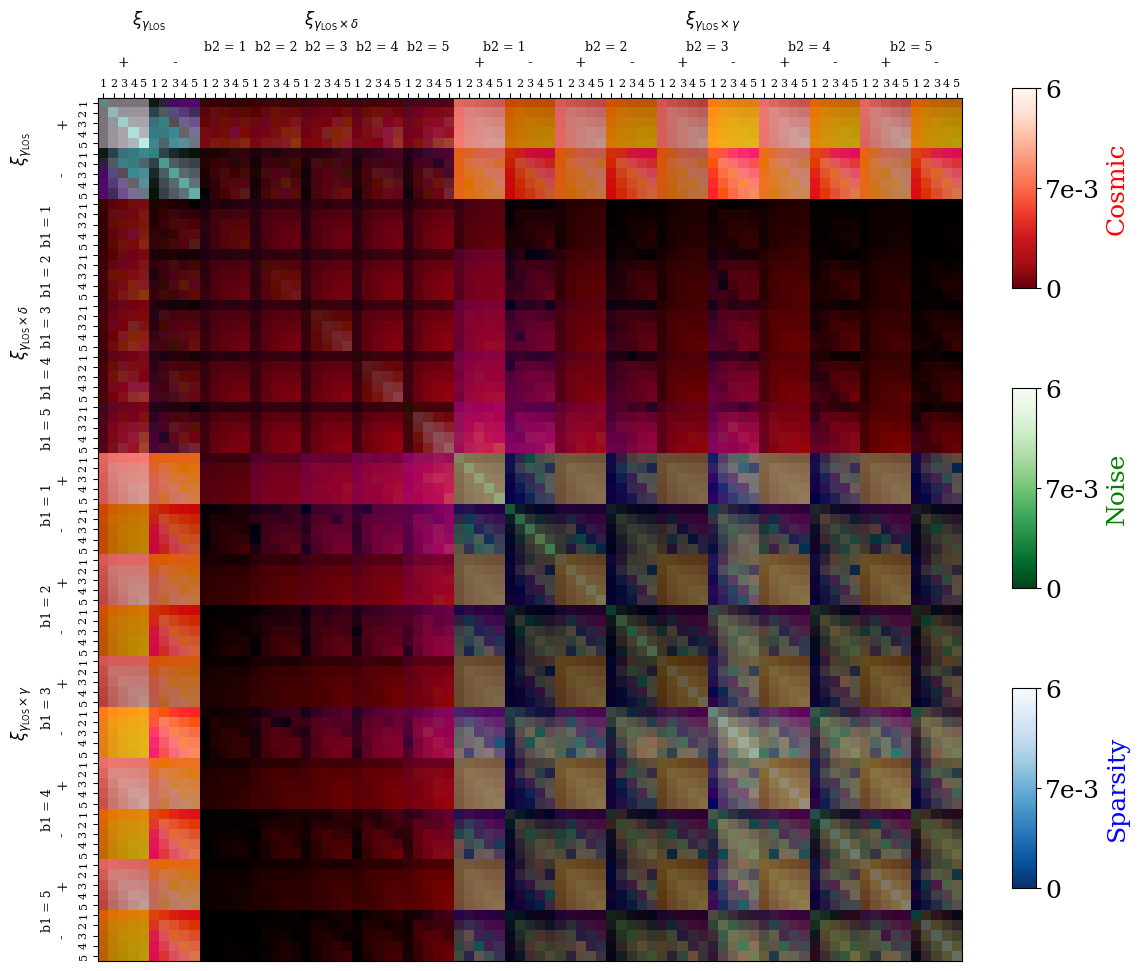

In [23]:
# Create the visualization
fig = plot_colored_covariance(matrices_data, scale=True, normalize=True, log_scale=True)
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Show the plot
fig.savefig("Covariance.png", bbox_inches='tight')
plt.show()

In [24]:
def plot_total_covariance(matrices_data, scale=True, log_scale=True, figsize=(12, 10)):
    """
    Creates a colored visualization of the three covariance matrices with separate colorbars.
    
    Args:
        matrices_data: Dictionary containing ncov, ccov, and scov matrices
        scale: scale the matrix by the corresponding correlations
        log_scale: Whether to use log scale for color intensities
        figsize: Size of the figure (width, height)
    """
    # Get the three matrices
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(matrices_data)

    total_mat  = noise_mat + cosmic_mat + sparsity_mat
    
    if scale:
        total_mat /= np.outer(correlations_list, correlations_list)
    
    if total_mat is None:
        raise ValueError("Could not construct matrix")
    
    # Apply log scale if required
    if log_scale:
        total_mat = np.log1p((np.abs(total_mat)))
    
    # Create the plot
    cmap = "coolwarm"  # Alternatives: "magma", "cividis", "RdBu", "viridis"
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(total_mat, cmap=cmap, aspect='equal')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Covariance", fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    
    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # Get matrix size to determine label positioning
    matrix_size = total_mat.shape[0]
    
    # Create custom tick positions and labels
    # Innermost labels (1-5 repeatedly)
    inner_ticks = np.arange(matrix_size)
    inner_labels = [(i % 5) + 1 for i in range(matrix_size)]
    
    # Create the figure with reduced distance between plot and colorbars
    # Adjust right margin to be closer to the plot
    plt.subplots_adjust(right=0.85)
    
    # Add first level (innermost) labels
    ax.set_xticks(inner_ticks)
    ax.set_yticks(inner_ticks)
    ax.set_xticklabels(inner_labels, fontsize=8)
    ax.set_yticklabels(inner_labels, fontsize=8, rotation = 90)
    
    # Define label positions with evenly spaced tiers
    # We need to ensure enough space for the additional tiers of labels
    plt.subplots_adjust(left=0.12, top=0.85, bottom=0.05)
    
    # Define evenly spaced offsets for the different tiers of labels
    middle_tier_offset = -4  # Increased from -3 for more even spacing
    outer_tier_offset = -5.5   # Increased from -6 for more even spacing
    extra_tier_offset = -8  # Increased from -10 for more even spacing
    
    # CORRECTED LABELS ACCORDING TO SPECIFICATIONS
    
    # Middle tier: +/- labels
    # "+" for first block of 5, "-" for next, nothing for next 5 blocks, alternating +/- for last 10 blocks
    middle_labels = []
    for i in range(matrix_size):
        block_idx = i // 5
        if block_idx == 0:
            middle_labels.append('+')
        elif block_idx == 1:
            middle_labels.append('-')
        elif block_idx < 7:  # blocks 2-6 (5 blocks)
            middle_labels.append('')
        else:  # blocks 7-16 (10 blocks)
            if (block_idx - 7) % 2 == 0:
                middle_labels.append('+')
            else:
                middle_labels.append('-')
    
    # Outer tier: numbering
    # Nothing for first 2 blocks, 1-5 for next 5 blocks, 1-5 for last 10 blocks (1 label per 2 blocks)
    extra_labels = []
    for i in range(matrix_size):
        block_idx = i // 5
        if block_idx < 2:
            extra_labels.append('')
        elif block_idx < 7:  # blocks 2-6 (5 blocks)
            extra_labels.append(str((block_idx - 1)))
        else:  # blocks 7-16 (10 blocks) - 1 label per 2 blocks
            label_num = (block_idx - 7) // 2 + 1
            if (block_idx - 7) % 2 == 0:  # Only add label on even blocks
                extra_labels.append(str(label_num))
            else:
                extra_labels.append('')
    
    # Extra tier: LL, Lp, Le
    # LL for first 2 blocks, Lp for next 5 blocks, Le for last 10 blocks
    outer_labels = []
    for i in range(matrix_size):
        block_idx = i // 5
        if block_idx < 2:
            outer_labels.append(r'$\xi_{\gamma_{{\rm LOS}}\cross \xi_{\gamma_{{\rm LOS}}$')
        elif block_idx < 7:  # blocks 2-6 (5 blocks)
            outer_labels.append(r'$\xi_{\gamma_{{\rm LOS}}\cross \delta$')
        else:  # blocks 7-16 (10 blocks)
            outer_labels.append(r'$\xi_{\gamma_{{\rm LOS}}\cross \xi$')
    
    # Function to add section label
    def add_section_label(pos_x, pos_y, label, offset, fontsize, is_x_axis=True):
        if label and is_x_axis:
            ax.text(pos_x, offset, label, ha='center', va='center', fontsize=fontsize)
        if label and not is_x_axis:
            ax.text(offset, pos_y, label, ha='center', va='center', fontsize=fontsize, rotation=90)
    
    # Add middle tier labels (+/-) - with spacing adjustment to avoid overlap
    for i in range(0, matrix_size, 5):
        if middle_labels[i]:
            # Only add label once per block
            add_section_label(i + 2, i + 2, middle_labels[i], middle_tier_offset, 10, True)
            add_section_label(i + 2, i + 2, middle_labels[i], middle_tier_offset, 10, False)
    
    # Add outer tier labels (numbers)
    # Nothing for first 2 blocks
    # 1-5 for next 5 blocks (blocks 2-6)
    for i in range(2, 7):
        center_pos = (i * 5) + 2
        add_section_label(center_pos, center_pos, "b2 = " + str(i-1), outer_tier_offset, 9, True)
        add_section_label(center_pos, center_pos, "b1 = " + str(i-1), outer_tier_offset, 9, False)
    
    # 1-5 for last 10 blocks (1 label per 2 blocks)
    for i in range(0, 5):
        # Position at the center of each pair of blocks
        center_pos = ((i * 2) + 7) * 5 + 4.5
        add_section_label(center_pos, center_pos, "b2 = " + str(i+1), outer_tier_offset, 9, True)
        add_section_label(center_pos, center_pos, "b1 = " + str(i+1), outer_tier_offset, 9, False)
    
    # Add extra tier labels (LL, Lp, Le) - only once per section
    # LL (first 2 blocks)
    add_section_label(4.5, 4.5, r'$\xi_{\gamma_\mathrm{LOS}}$', extra_tier_offset, 12, True)
    add_section_label(4.5, 4.5, r'$\xi_{\gamma_\mathrm{LOS}}$', extra_tier_offset, 12, False)
    
    # Lp (next 5 blocks)
    add_section_label(22.5, 22.5, r'$\xi_{\gamma_\mathrm{LOS} \times \delta}$', extra_tier_offset, 12, True)
    add_section_label(22.5, 22.5, r'$\xi_{\gamma_\mathrm{LOS} \times \delta}$', extra_tier_offset, 12, False)
    
    # Le (last 10 blocks)
    add_section_label(60, 60, r'$\xi_{\gamma_\mathrm{LOS} \times \gamma}$', extra_tier_offset, 12, True)
    add_section_label(60, 60, r'$\xi_{\gamma_\mathrm{LOS} \times \gamma}$', extra_tier_offset, 12, False)
    
    return fig

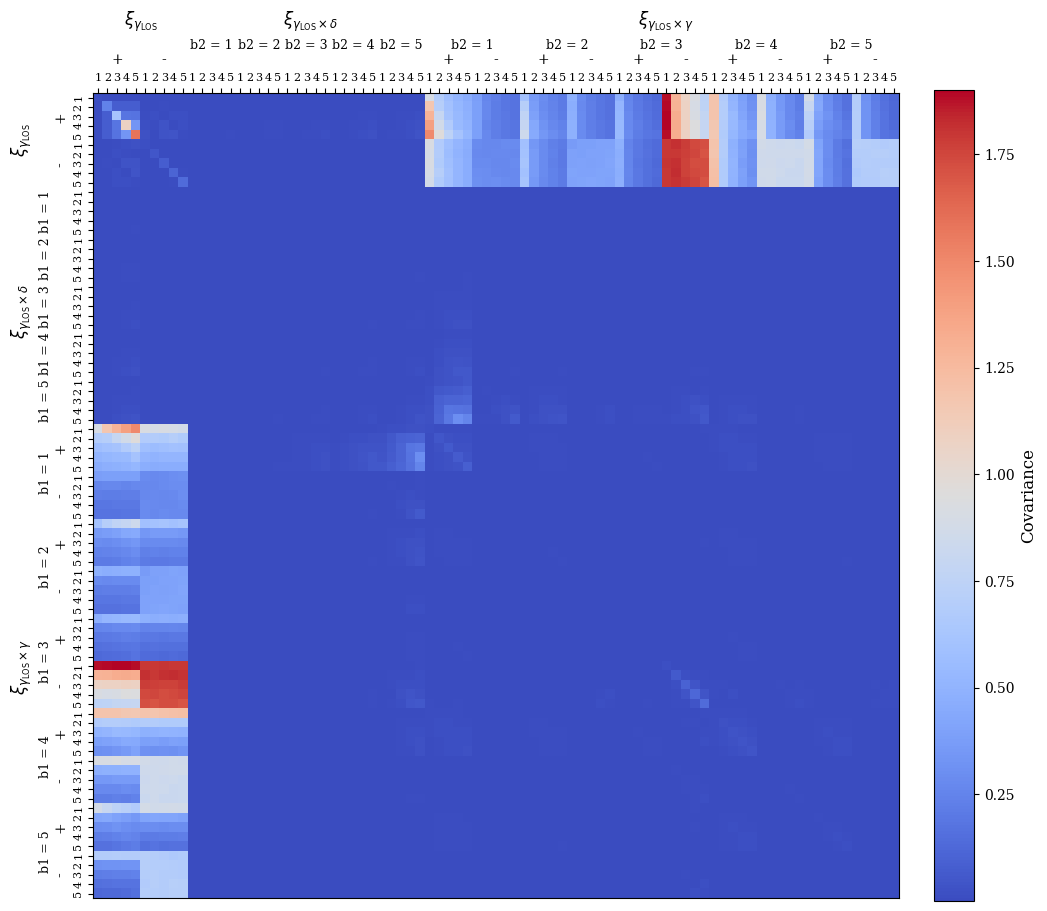

In [25]:
# Create the visualization
fig = plot_total_covariance(matrices_data, scale=True, log_scale=True)
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Show the plot
# fig.savefig("Covariance.png", bbox_inches='tight')
plt.show()

### 4 Plotting individual matrices <a id='usefulfunctions'></a>

In [26]:
Nbinb = len(binparams['redshifts'])-1

In [27]:
n_corr = {'LL': 2,
 'Lp': 1,
 'Le': 2
    }

Nbinas = {'LL': Nbina_LL,
 'Lp': Nbina_Lp,
 'Le': Nbina_Le
    }

sizes = {'LL': n_corr['LL'] * Nbinas['LL'],
 'Lp': n_corr['Lp'] * Nbinb * Nbinas['Lp'],
 'Le': n_corr['Le'] * Nbinb * Nbinas['Le']
    }

indices = {'LL': (0, sizes['LL']),
 'Lp': (sizes['LL'], sizes['LL'] + sizes['Lp']),
 'Le': (sizes['LL'] + sizes['Lp'], sizes['LL'] + sizes['Lp'] + sizes['Le'])
    }

correlation_names = {'LL': r'$\xi_{\gamma_\mathrm{LOS}}$',
 'Lp': r'$\xi_{\gamma_\mathrm{LOS} \times \delta}$',
 'Le': r'$\xi_{\gamma_\mathrm{LOS} \times \gamma}$'
    }

def extract_block(matrix, corr1, corr2):
    """
    Extracts a specified block from the covariance matrix.
    
    Args:
        matrix: Full covariance matrix
        block_name: Name of the block to extract ("LLLL", "LpLp", "LeLe", "LLLp", "LLLe", LpLe")
        Nbina: Number of angular bins
    
    Returns:
        Extracted submatrix
    """
    
    return matrix[indices[corr1][0]:indices[corr1][1], indices[corr2][0]:indices[corr2][1]]


def extract_redshift_bin(submatrix, corr1, corr2, redshifts = (1,1)):
    
    redshift_index1 = redshifts[0] - 1
    redshift_index2 = redshifts[1] - 1

    start1 = redshift_index1 * n_corr[corr1] * Nbinas[corr1]
    end1 = (redshift_index1+1) * n_corr[corr1] * Nbinas[corr1]
    
    start2 = redshift_index2 * n_corr[corr2] * Nbinas[corr2]
    end2 = (redshift_index2+1) * n_corr[corr2] * Nbinas[corr2]

    result = submatrix[start1:end1, start2:end2]
    
    return result



In [28]:
def plot_covariance_block(matrices_data, corrs, 
                          scale=True, normalize=True, log_scale=True, figsize=(8, 6),
                          plot_noise=True, plot_cosmic=True, plot_sparsity=True, redshift_bins = None):
    """
    Plots a specific block of the covariance matrix, allowing selective inclusion of noise, cosmic, and sparsity components.
    """

    corr1 = corrs[0]
    corr2 = corrs[1]
    
    stop = False

    if redshift_bins is not None:
        b1_name = str(redshift_bins[0])
        b2_name = str(redshift_bins[1])
        for i, redshift_bin in enumerate(redshift_bins):
            if type(redshift_bin) != int or redshift_bin > Nbinb or 1 > redshift_bin:
                print(f'Error: Invalid redshift binning - bins must be integers from 1 to {Nbinb}')
                stop = True
            elif corrs[i] == 'LL' and redshift_bin > 1:
                print(f'Error: No redshift binning for LOS shear, only valid index is 1')
                stop = True
    else:
        b1_name = 'b'
        b2_name = 'b'

    if not stop:
        noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(matrices_data)
        
        if scale:
            noise_mat /= np.outer(correlations_list, correlations_list)
            cosmic_mat /= np.outer(correlations_list, correlations_list)
            sparsity_mat /= np.outer(correlations_list, correlations_list)
        
        noise_mat = extract_block(noise_mat, corr1, corr2)
        cosmic_mat = extract_block(cosmic_mat, corr1, corr2)
        sparsity_mat = extract_block(sparsity_mat, corr1, corr2)
    
        if redshift_bins is not None:
            noise_mat = extract_redshift_bin(noise_mat, corr1, corr2, redshifts = redshift_bins)
            cosmic_mat = extract_redshift_bin(cosmic_mat, corr1, corr2, redshifts = redshift_bins)
            sparsity_mat = extract_redshift_bin(sparsity_mat, corr1, corr2, redshifts = redshift_bins)
            
    
        eps = 8e-6
        eps = max(eps, np.min(np.abs([noise_mat, cosmic_mat, sparsity_mat])))
        
        if log_scale:
            noise_mat = np.log1p((np.abs(noise_mat)) / eps)
            cosmic_mat = np.log1p((np.abs(cosmic_mat)) / eps)
            sparsity_mat = np.log1p((np.abs(sparsity_mat)) / eps)
    
        # Select matrices to plot based on user input
        components = []
        colors = []
        
        if plot_noise:
            components.append(noise_mat)
            colors.append(1)  # Green
        if plot_cosmic:
            components.append(cosmic_mat)
            colors.append(0)  # Red
        if plot_sparsity:
            components.append(sparsity_mat)
            colors.append(2)  # Blue
    
        # Normalize if enabled
        if normalize and components:
            max_val = max(np.max(mat) for mat in components)
            if max_val > 0:
                components = [mat / max_val for mat in components]
    
        # Initialize RGB matrix
        rgb_matrix = np.zeros(noise_mat.shape + (3,))
        
        # Assign selected components to RGB channels
        for mat, color in zip(components, colors):
            rgb_matrix[..., color] = mat  
    
        # Plot the covariance block
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(rgb_matrix, aspect='equal')
        ax.set_title(r'$[$'+correlation_names[corr1]+ '(a; ' + b1_name + '), '+correlation_names[corr2]+ '(a; ' + b2_name + r')$]$')
        plt.show()

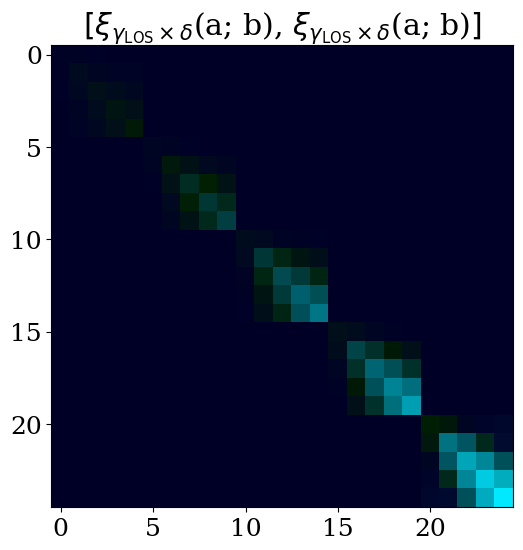

In [29]:
bbins = (1,4)
bbins = None

plot_covariance_block(matrices_data, ('Lp', 'Lp'), plot_noise=True, plot_cosmic=False, plot_sparsity=True, redshift_bins = bbins)

### 5 Signal vs noise <a id='usefulfunctions'></a>

In [30]:
class LensDistribution:
    """
    This class produces anything useful related to the statistics of lenses
    and their binning in angular separation
    """
    
    
    def __init__(self, Nlens=1e5, sky_coverage=15e3, Nbin=10, Thetamax=3e2):
        """
        Arguments:
        - Nlens: number of lenses we can use
        - sky_coverage: area of the survey footprint, in deg2 
        - Nbin: number of bins of angular separation
        - Thetamax: maximum angular separation, in arcmin
        
        All the angular attributes will be expressed in rad.
        """
        
        # Lens number and density
        self.Nlens = Nlens
        self.Omegatot = sky_coverage * (np.pi / 180)**2 # in rad2
        self.density = Nlens / self.Omegatot
        
        # Binning
        self.Nbin = Nbin
        Omega_arcmin2 = np.pi * Thetamax**2 / Nbin
        self.Omega = Omega_arcmin2 * (np.pi / 180 / 60)**2 # in rad2
        self.Omegas = self.Omega * np.ones(Nbin) # in rad2
        # the list of Omegas is in case we want to have different bin sizes
        self.limits = np.sqrt(self.Omega / np.pi * np.arange(Nbin + 1)) # in rad
        
        # "Centres" of the bins, taken as the median separation
        self.Thetas = np.sqrt((self.limits[1:]**2 + self.limits[:-1]**2) / 2) # in rad

lens_dist = LensDistribution(Nlens=1e5, sky_coverage=15e3, Nbin=5, Thetamax=3e2)
Thetas = lens_dist.Thetas

In [31]:
def compute_variance(cov, corr, pm):
    
    var = np.diagonal(cov)

    if corr == 'Lp':
        rms = np.sqrt(np.abs(var))

    elif pm == 'plus':
        rms = np.sqrt(np.abs(var[:Nbinas[corr]]))

    elif pm == 'minus':
        rms = np.sqrt(np.abs(var[Nbinas[corr]:]))

    else:
        rms = 0
        print('Error!!')

    return rms

In [32]:
def plot_signal_vs_noise(matrix, corr, redshift, pm):

    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(matrices_data)

    variance = []
    blocks = []
    
    for matrix in [noise_mat, cosmic_mat, sparsity_mat]:

        submatrix = extract_block(matrix, corr, corr) 
    
        block = extract_redshift_bin(submatrix, corr, corr, redshifts = (redshift,redshift))

        blocks.append(block)
        
        variance.append(compute_variance(block, corr, pm))
    
    total_covariance = blocks[0]+blocks[1]+blocks[2]
    
    total_variance = compute_variance(total_covariance, corr, pm)
    
    if corr == 'LL':
        correlations = np.abs(matrices_data[corr+corr][pm + '_correlation'])

        if redshift != 1:
            print("Warning! Redshift must equal 1 for LL")
    
    elif corr == 'Lp':
        correlations = np.abs(matrices_data[corr+corr]['correlation{b1}'][redshift-1])
    elif corr == 'Le':
        correlations = np.abs(matrices_data[corr+corr][pm + '_correlation{b1}'][redshift-1])

    fig, ax = plt.subplots(figsize=(12, 6))  
    
    ax.semilogy(Thetas, correlations, 'o-', label="signal", color = 'orange')
    ax.semilogy(Thetas, total_variance, color='black', label="total uncertainty")
    ax.fill_between(Thetas, total_variance, alpha=0.2, color='black')  # Corrected
    
    ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
    ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
    ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")
    
    ax.set_ylabel(correlation_names[corr])
    ax.set_xlim([min(Thetas), max(Thetas)])
    ax.set_xlabel(r"bin median separation $\bar{\Theta}_a$ [deg]")
    
    ax.legend(loc = 'lower right')  # Add legend
    plt.tight_layout()
    plt.savefig('Signal_vs_Noise.pdf')
    plt.show()

         

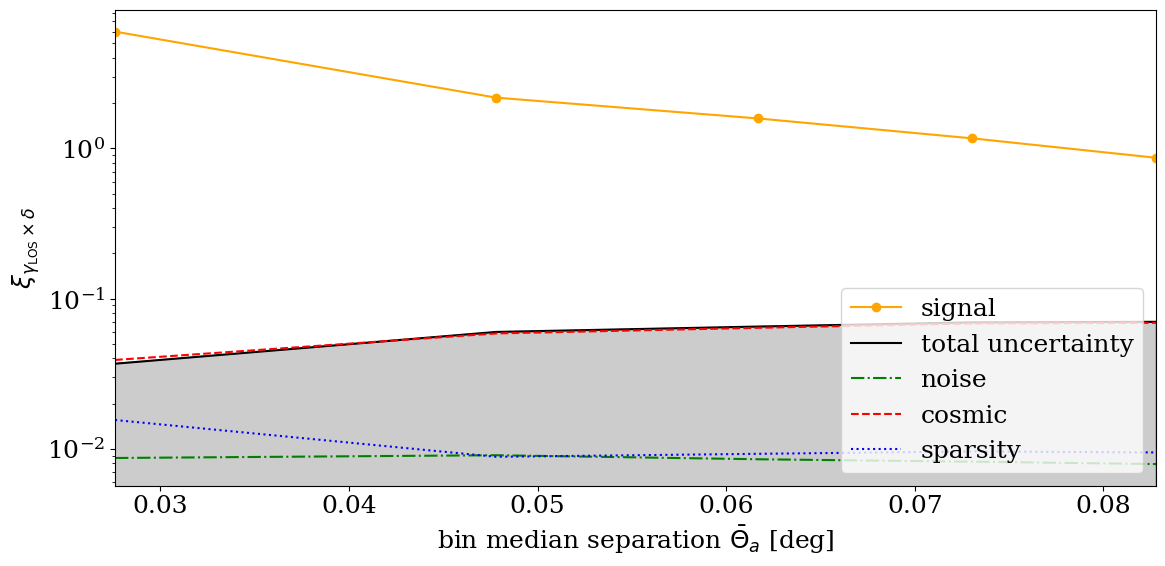

In [33]:
plot_signal_vs_noise(matrices_data, 'Lp', 3, 'minus')

In [34]:
def plot_signal_vs_noise2(matrices_data, corr, Nbinb):
    
    noise_mat, cosmic_mat, sparsity_mat = construct_large_matrices(matrices_data)
    
    pm_values = ['plus', 'minus'] if corr in ['LL', 'Le'] else ['plus']  # Two columns for LL and Le
    ncols = len(pm_values)  # Number of columns
    nrows = Nbinb  # Number of rows

    if corr == 'Lp':
        nn = 1
    else:
        nn = 2
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12 * nn, 6 * nrows), squeeze=False)  # Keep 2D array
    
    for i, redshift in enumerate(range(1, Nbinb + 1)):
        for j, pm in enumerate(pm_values):
            ax = axes[i, j] if nrows > 1 else axes[j]  # Handle single-row case
            
            variance = []
            blocks = []
            
            for matrix in [noise_mat, cosmic_mat, sparsity_mat]:
                submatrix = extract_block(matrix, corr, corr)
                block = extract_redshift_bin(submatrix, corr, corr, redshifts=(redshift, redshift))
                blocks.append(block)
                variance.append(compute_variance(block, corr, pm))
            
            total_covariance = sum(blocks)
            total_variance = compute_variance(total_covariance, corr, pm)
            
            if corr == 'LL':
                correlations = np.abs(matrices_data[corr+corr][pm + '_correlation'])
                if redshift != 1:
                    print("Warning! Redshift must equal 1 for LL")
            elif corr == 'Lp':
                correlations = np.abs(matrices_data[corr+corr]['correlation{b1}'][redshift-1])
            elif corr == 'Le':
                correlations = np.abs(matrices_data[corr+corr][pm + '_correlation{b1}'][redshift-1])
            
            ax.semilogy(Thetas, correlations, 'o-', label="signal", color='orange')
            ax.semilogy(Thetas, total_variance, color='black', label="total uncertainty")
            ax.fill_between(Thetas, total_variance, alpha=0.2, color='black')
            ax.semilogy(Thetas, variance[0], '-.', color='green', label="noise")
            ax.semilogy(Thetas, variance[1], '--', color='red', label="cosmic")
            ax.semilogy(Thetas, variance[2], ':', color='blue', label="sparsity")
            
            ax.set_ylabel(correlation_names[corr])
            ax.set_xlim([min(Thetas), max(Thetas)])
            ax.set_xlabel(r"bin median separation $\bar{\Theta}_a$ [deg]")
            if i == 0 and corr != 'Lp':
                ax.set_title(f" {pm}, b = {redshift}")
            else:
                ax.set_title(f" b = {redshift}")
            ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('Signal_vs_Noise_array.pdf')
    plt.show()


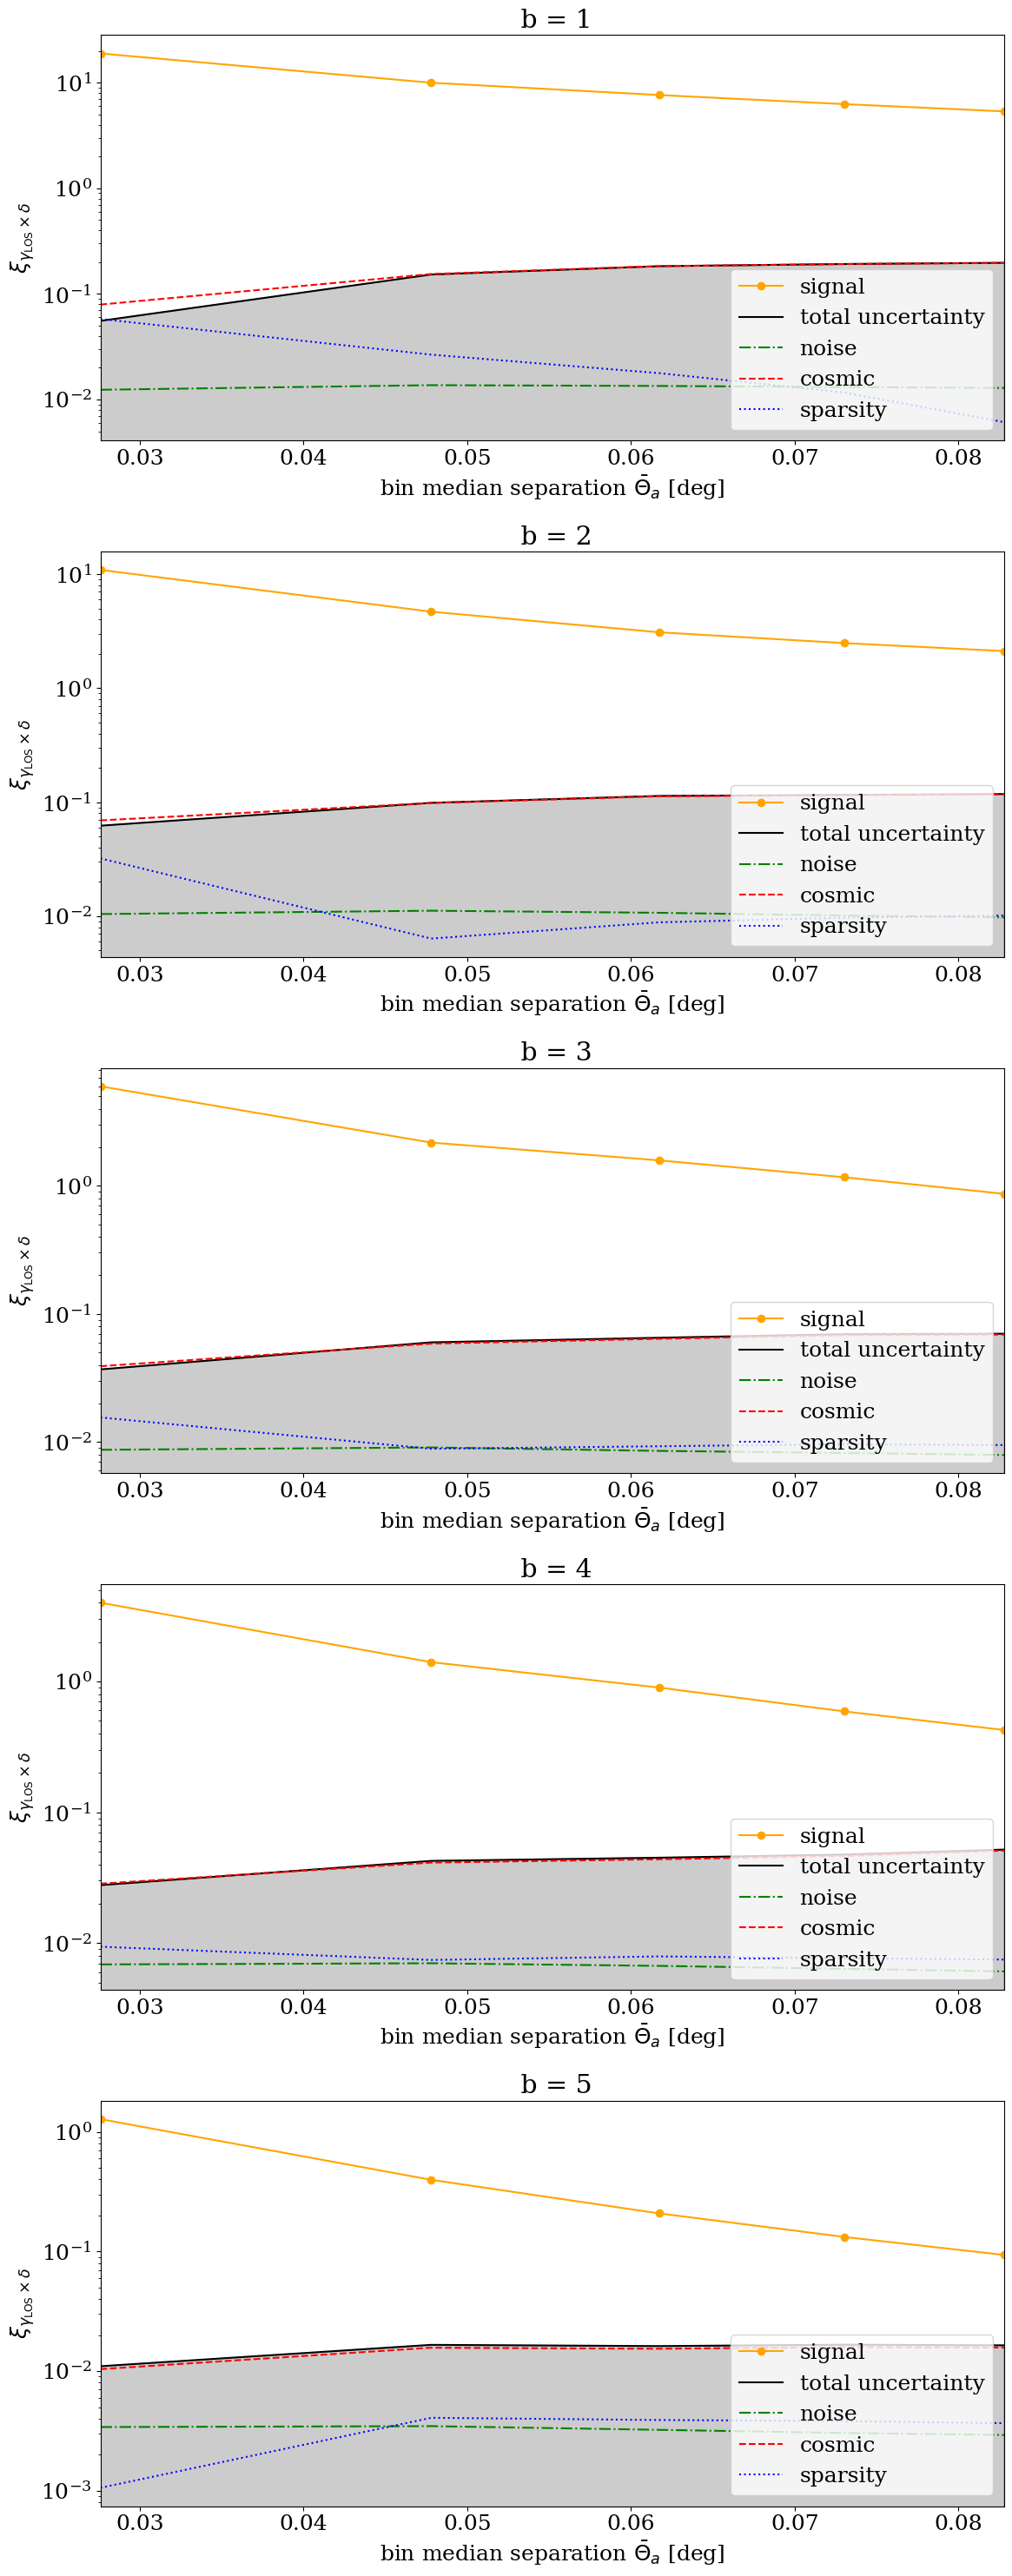

In [35]:
plot_signal_vs_noise2(matrices_data, 'Lp', 5)